## Function 4: Geometry Operations 📐

In this notebook, you'll learn how to build the `geometry_operations()` function step by step. This is where you start performing geometric calculations and transformations such as buffers, centroids, areas, lengths, and simplification.

### 🎯 What This Function Does
- Create buffers around geometries
- Calculate centroids (geometric centers)
- Measure areas and lengths
- Simplify complex geometries
- Return structured results with statistics

### 🔧 Function Signature
```python
def geometry_operations(gdf, operation='buffer', **kwargs):
    """
    Args:
        gdf (geopandas.GeoDataFrame): Input spatial dataset
        operation (str): Geometry operation to perform
        **kwargs: Operation-specific parameters
    
    Returns:
        dict: Result GeoDataFrame plus summary statistics
    """
```

### 📍 Where This Function Goes:
**Target File**: `src/geopandas_basics.py`  
**Function Name**: `geometry_operations()`  
**Replace**: The placeholder function with your working code

---

### ⚙️ Step 0: Select the Correct Python Kernel

Before running any cells, make sure the notebook is using the correct Python environment.

**Check the kernel in the top-right corner of the notebook.**

The correct Python environment is **python-gis-development (.venv)**  
It may appear with a Python version, for example:  
**python-gis-development (3.11.15) (Python 3.11.15) .venv/bin/python**



If the kernel is **python-gis-development (.venv)**, you can start running cells below.

Steps to select the correct kernel:
1. Click on the kernel (top right corner of the notebook) if it is not **python-gis-development (.venv)** or if it says "Select Kernel"
2. Select **python-gis-development (.venv)**
3. If you do not see the kernel in the list, click on "Select Another Kernel..."  
    a. Click on Python Environments...   
    b. Select **python-gis-development (.venv)**

Once the correct kernel is selected, you can start running cells below.

### 📚 Step 1: Load Data

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from typing import Dict, Any

# Load datasets
cities = gpd.read_file('../../data/cities/ne_cities_us.geojson')
ecoregions = gpd.read_file('../../data/ecoregions/epa_level3_western_us.geojson')

# Transform to projected CRS for accurate measurements (meters)
cities_utm = cities.to_crs('EPSG:32611')  # UTM Zone 11N
ecoregions_utm = ecoregions.to_crs('EPSG:32611')

print(f"✅ Cities: {len(cities_utm)} features in {cities_utm.crs}")
print(f"✅ Ecoregions: {len(ecoregions_utm)} features in {ecoregions_utm.crs}")

✅ Cities: 281 features in EPSG:32611
✅ Ecoregions: 188 features in EPSG:32611


### 🎈 Step 2: Buffer Operation

**💡 This pattern will be used in our function!**

Original geometry type: Point
Buffered geometry type: Polygon
Buffer distance: 50000 meters


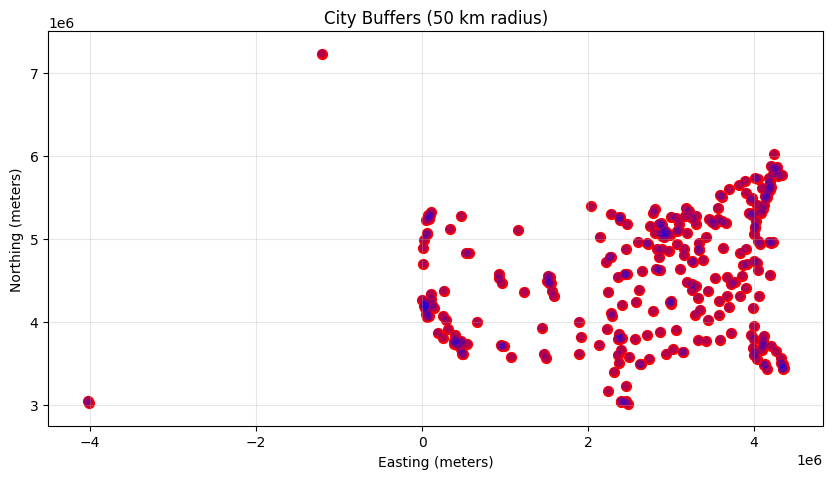

In [2]:
# 💡 Create buffer using .buffer() method
distance = 50000  # 50 km in meters
buffered_cities = cities_utm.copy()
buffered_cities.geometry = cities_utm.geometry.buffer(distance)

print(f"Original geometry type: {cities_utm.geometry.geom_type.iloc[0]}")
print(f"Buffered geometry type: {buffered_cities.geometry.geom_type.iloc[0]}")
print(f"Buffer distance: {distance} meters")

# Basic visualization
fig, ax = plt.subplots(figsize=(10, 6))
cities_utm.plot(ax=ax, color='red', markersize=50, label='Cities')
buffered_cities.plot(ax=ax, alpha=0.3, color='blue', label='50km Buffer')
ax.set_title('City Buffers (50 km radius)')
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.grid(True, alpha=0.3)
plt.show()

### 🗺️ Step 3: Visualization 1 - Multi-Distance Buffer Rings

See how buffer distance creates expanding zones


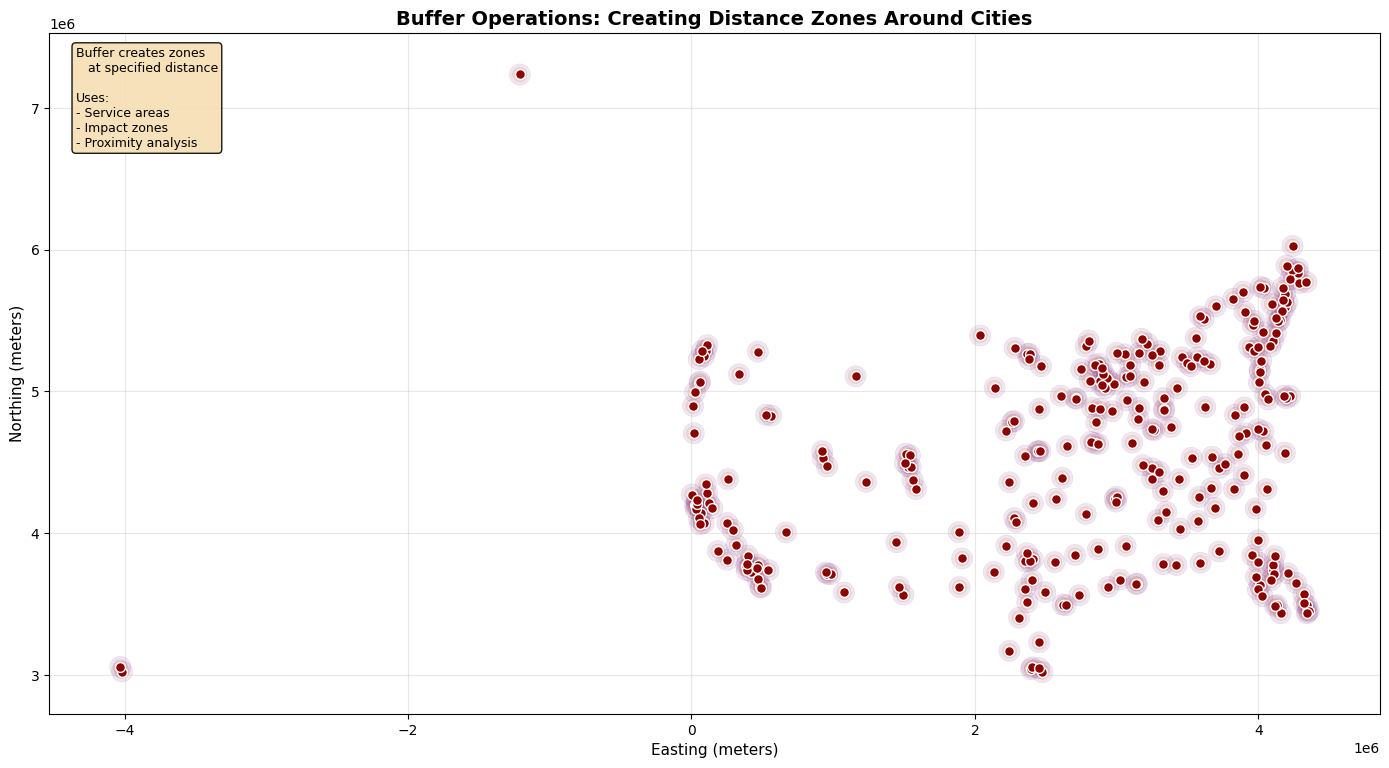

🎯 Buffer zones created at:
   • 10 km: 10,000 meters radius
   • 25 km: 25,000 meters radius
   • 50 km: 50,000 meters radius
   • 75 km: 75,000 meters radius


In [3]:
# Create multiple buffer distances to show the effect
fig, ax = plt.subplots(figsize=(14, 9))

# Original cities
cities_utm.plot(ax=ax, color='darkred', markersize=50, label='Cities', zorder=5, edgecolor='white', linewidth=1)

# Multiple buffer distances with decreasing opacity
buffer_distances = [
    (10000, 0.25, 'blue', '10 km'),
    (25000, 0.20, 'green', '25 km'),
    (50000, 0.15, 'orange', '50 km'),
    (75000, 0.10, 'purple', '75 km')
]

for distance, alpha, color, label in buffer_distances:
    buffered = cities_utm.copy()
    buffered.geometry = cities_utm.geometry.buffer(distance)
    buffered.plot(ax=ax, alpha=alpha, color=color, label=f'{label} buffer', edgecolor='black', linewidth=0.3)

ax.set_title('Buffer Operations: Creating Distance Zones Around Cities', fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (meters)', fontsize=11)
ax.set_ylabel('Northing (meters)', fontsize=11)
ax.grid(True, alpha=0.3)

# Add informative text
info_text = "Buffer creates zones\n   at specified distance\n\n"
info_text += "Uses:\n"
info_text += "- Service areas\n"
info_text += "- Impact zones\n"
info_text += "- Proximity analysis"
ax.text(0.02, 0.98, info_text,
       transform=ax.transAxes,
       verticalalignment='top',
       horizontalalignment='left',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
       fontsize=9)

plt.tight_layout()
plt.show()

print("🎯 Buffer zones created at:")
for dist, _, _, label in buffer_distances:
    print(f"   • {label}: {dist:,} meters radius")


### 📍 Step 4: Centroid Operation

**💡 This pattern will be used in our function!**

Original geometry type: Polygon
Centroid geometry type: Point
Feature count preserved: 188 == 188


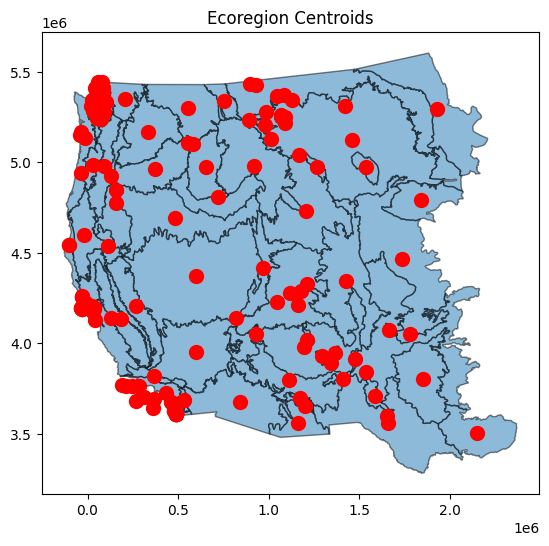

In [4]:
# 💡 Calculate centroids using .centroid property
centroids = ecoregions_utm.copy()
centroids.geometry = ecoregions_utm.geometry.centroid

print(f"Original geometry type: {ecoregions_utm.geometry.geom_type.iloc[0]}")
print(f"Centroid geometry type: {centroids.geometry.geom_type.iloc[0]}")
print(f"Feature count preserved: {len(centroids)} == {len(ecoregions_utm)}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ecoregions_utm.plot(ax=ax, alpha=0.5, edgecolor='black', label='Ecoregions')
centroids.plot(ax=ax, color='red', markersize=100, label='Centroids')

ax.set_title('Ecoregion Centroids')
plt.show()

### 📏 Step 5: Area Calculation

**💡 This pattern will be used in our function!**

In [ ]:
# 💡 Calculate areas using .area property
areas = ecoregions_utm.geometry.area
print(f"Areas calculated: {len(areas)} values")
print(f"Type: {type(areas)}")
print()

# 💡 Add as new column to GeoDataFrame
result_gdf = ecoregions_utm.copy()
result_gdf['area'] = areas

# 💡 Calculate statistics
print(f"Total area: {areas.sum():,.0f} m²")
print(f"Mean area: {areas.mean():,.0f} m²")
print(f"Min area: {areas.min():,.0f} m²")
print(f"Max area: {areas.max():,.0f} m²")
print()

# Show largest ecoregion
largest_idx = areas.idxmax()
print(f"Largest ecoregion: {result_gdf.loc[largest_idx, 'eco_name']}")
print(f"Area: {result_gdf.loc[largest_idx, 'area']:,.0f} m²")

### 📐 Step 6: Length Calculation

**💡 This pattern will be used in our function!**

In [ ]:
# 💡 Calculate perimeter/length using .length property
lengths = ecoregions_utm.geometry.length
print(f"Lengths calculated: {len(lengths)} values")
print()

# 💡 Add as new column
result_gdf = ecoregions_utm.copy()
result_gdf['length'] = lengths

# 💡 Calculate statistics
print(f"Total perimeter: {lengths.sum():,.0f} meters")
print(f"Mean perimeter: {lengths.mean():,.0f} meters")
print(f"Min perimeter: {lengths.min():,.0f} meters")
print(f"Max perimeter: {lengths.max():,.0f} meters")

### 🎨 Step 7: Simplify Operation

**💡 This pattern will be used in our function!**

In [ ]:
# 💡 Simplify geometries using .simplify() method
tolerance = 5000  # 5 km tolerance
simplified = ecoregions_utm.copy()
simplified.geometry = ecoregions_utm.geometry.simplify(tolerance)

print(f"Simplification tolerance: {tolerance} meters")
print(f"Feature count preserved: {len(simplified)} == {len(ecoregions_utm)}")

# Compare complexity (number of coordinates)
original_coords = sum(len(geom.exterior.coords) for geom in ecoregions_utm.geometry if geom.geom_type == 'Polygon')
simplified_coords = sum(len(geom.exterior.coords) for geom in simplified.geometry if geom.geom_type == 'Polygon')

print(f"Original coordinates: {original_coords:,}")
print(f"Simplified coordinates: {simplified_coords:,}")
print(f"Reduction: {(1 - simplified_coords/original_coords)*100:.1f}%")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ecoregions_utm.plot(ax=ax1, edgecolor='black', facecolor='lightblue')
ax1.set_title('Original')
simplified.plot(ax=ax2, edgecolor='black', facecolor='lightcoral')
ax2.set_title(f'Simplified (tolerance={tolerance}m)')
plt.show()

### 🗺️ Step 8: Visualization 3 - Simplification Sequence

See how simplification reduces geometry complexity:


In [ ]:
# Pick one ecoregion to demonstrate simplification
sample_eco = ecoregions_utm.iloc[0:1].copy()

# Create different levels of simplification
original = sample_eco
simplified_5k = sample_eco.copy()
simplified_5k.geometry = sample_eco.geometry.simplify(5000)
simplified_20k = sample_eco.copy()
simplified_20k.geometry = sample_eco.geometry.simplify(20000)
simplified_50k = sample_eco.copy()
simplified_50k.geometry = sample_eco.geometry.simplify(50000)

# Count vertices
def count_vertices(gdf):
    return len(gdf.iloc[0].geometry.exterior.coords)

original_vertices = count_vertices(original)
vertices_5k = count_vertices(simplified_5k)
vertices_20k = count_vertices(simplified_20k)
vertices_50k = count_vertices(simplified_50k)

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

# Original
original.plot(ax=axes[0], edgecolor='black', facecolor='lightblue', linewidth=1.5)
axes[0].set_title(f"Original\n{original_vertices} vertices\n100% detail", 
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

# Moderate simplification (5km)
simplified_5k.plot(ax=axes[1], edgecolor='black', facecolor='lightgreen', linewidth=1.5)
reduction_5k = (1 - vertices_5k/original_vertices) * 100
axes[1].set_title(f"Simplified (5 km tolerance)\n{vertices_5k} vertices\n{reduction_5k:.1f}% reduced", 
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

# Aggressive simplification (20km)
simplified_20k.plot(ax=axes[2], edgecolor='black', facecolor='orange', linewidth=1.5)
reduction_20k = (1 - vertices_20k/original_vertices) * 100
axes[2].set_title(f"Simplified (20 km tolerance)\n{vertices_20k} vertices\n{reduction_20k:.1f}% reduced", 
                 fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('Easting (m)')
axes[2].set_ylabel('Northing (m)')

# Very aggressive simplification (50km)
simplified_50k.plot(ax=axes[3], edgecolor='black', facecolor='red', linewidth=1.5)
reduction_50k = (1 - vertices_50k/original_vertices) * 100
axes[3].set_title(f"Simplified (50 km tolerance)\n{vertices_50k} vertices\n{reduction_50k:.1f}% reduced", 
                 fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlabel('Easting (m)')
axes[3].set_ylabel('Northing (m)')

plt.suptitle("Simplification: Reducing Geometry Complexity", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("🎯 Simplification results:")
print(f"   Original: {original_vertices} vertices")
print(f"   5km tolerance: {vertices_5k} vertices ({reduction_5k:.1f}% reduction)")
print(f"   20km tolerance: {vertices_20k} vertices ({reduction_20k:.1f}% reduction)")
print(f"   50km tolerance: {vertices_50k} vertices ({reduction_50k:.1f}% reduction)")
print("\n   Higher tolerance = fewer vertices = simpler geometry")
print("   Use for: faster rendering, smaller file sizes, generalized maps")


### 🔧 Step 9: Building Result Dictionary

**💡 This shows our return format!**

In [ ]:
# 💡 Our function returns a dictionary with 'result', 'statistics', and 'operation'
result_dict = {
    'operation': 'area',
    'result': result_gdf,
    'statistics': {
        'total_area': areas.sum(),
        'mean_area': areas.mean(),
        'min_area': areas.min(),
        'max_area': areas.max()
    }
}

print("Result dictionary structure:")
print(f"  operation: {result_dict['operation']}")
print(f"  result: GeoDataFrame with {len(result_dict['result'])} features")
print(f"  statistics: {result_dict['statistics']}")

### 🏗️ Step 10: Building the Complete Function

Now let's put everything together into a reusable function. This is what you will implement in `src/geopandas_basics.py`.

In [ ]:
import geopandas as gpd
from typing import Dict, Any

def geometry_operations(
    gdf: gpd.GeoDataFrame,
    operation: str = 'buffer',
    **kwargs
) -> Dict[str, Any]:
    """
    Perform fundamental geometry operations on spatial data.
    
    Supports multiple geometric operations:
    - 'buffer': Create buffers around geometries
    - 'centroid': Calculate geometric centers
    - 'area': Calculate polygon areas
    - 'length': Calculate line lengths/perimeters
    - 'simplify': Generalize geometries
    
    Args:
        gdf: Input GeoDataFrame
        operation: Operation to perform
        **kwargs: Operation-specific parameters:
            - buffer: distance (float, required)
            - simplify: tolerance (float, required)
            
    Returns:
        Dictionary containing:
        - 'result': GeoDataFrame with operation results
        - 'statistics': Dictionary of computed statistics
        - 'operation': Name of operation performed
        
    Raises:
        ValueError: If operation is invalid or parameters are missing
    """
    valid_operations = ['buffer', 'centroid', 'area', 'length', 'simplify']
    
    if operation not in valid_operations:
        raise ValueError(f"Invalid operation '{operation}'. Must be one of: {valid_operations}")
    
    result_dict = {
        'operation': operation,
        'statistics': {}
    }
    
    if operation == 'buffer':
        if 'distance' not in kwargs:
            raise ValueError("Buffer operation requires 'distance' parameter")
        
        distance = kwargs['distance']
        result_gdf = gdf.copy()
        result_gdf.geometry = gdf.geometry.buffer(distance)
        
        result_dict['result'] = result_gdf
        result_dict['statistics']['buffer_distance'] = distance
        result_dict['statistics']['feature_count'] = len(result_gdf)
        
    elif operation == 'centroid':
        result_gdf = gdf.copy()
        result_gdf.geometry = gdf.geometry.centroid
        
        result_dict['result'] = result_gdf
        result_dict['statistics']['feature_count'] = len(result_gdf)
        
    elif operation == 'area':
        result_gdf = gdf.copy()
        areas = gdf.geometry.area
        result_gdf['area'] = areas
        
        result_dict['result'] = result_gdf
        result_dict['statistics']['total_area'] = areas.sum()
        result_dict['statistics']['mean_area'] = areas.mean()
        result_dict['statistics']['min_area'] = areas.min()
        result_dict['statistics']['max_area'] = areas.max()
        
    elif operation == 'length':
        result_gdf = gdf.copy()
        lengths = gdf.geometry.length
        result_gdf['length'] = lengths
        
        result_dict['result'] = result_gdf
        result_dict['statistics']['total_length'] = lengths.sum()
        result_dict['statistics']['mean_length'] = lengths.mean()
        result_dict['statistics']['min_length'] = lengths.min()
        result_dict['statistics']['max_length'] = lengths.max()
        
    elif operation == 'simplify':
        if 'tolerance' not in kwargs:
            raise ValueError("Simplify operation requires 'tolerance' parameter")
        
        tolerance = kwargs['tolerance']
        result_gdf = gdf.copy()
        result_gdf.geometry = gdf.geometry.simplify(tolerance)
        
        result_dict['result'] = result_gdf
        result_dict['statistics']['tolerance'] = tolerance
        result_dict['statistics']['feature_count'] = len(result_gdf)
    
    return result_dict

### ✨ Step 11: Test Your Function

Let's test our complete function with different scenarios:

In [ ]:
# Test 1: Buffer
print("Test 1: Buffer operation")
result = geometry_operations(cities_utm, 'buffer', distance=50000)
print(f"✅ Operation: {result['operation']}")
print(f"✅ Result features: {len(result['result'])}")
print(f"✅ Statistics: {result['statistics']}")
print()

# Test 2: Centroid
print("Test 2: Centroid operation")
result = geometry_operations(ecoregions_utm, 'centroid')
print(f"✅ Operation: {result['operation']}")
print(f"✅ Geometry type: {result['result'].geometry.geom_type.iloc[0]}")
print()

# Test 3: Area
print("Test 3: Area calculation")
result = geometry_operations(ecoregions_utm, 'area')
print(f"✅ Total area: {result['statistics']['total_area']:,.0f} m²")
print(f"✅ Mean area: {result['statistics']['mean_area']:,.0f} m²")
print()

# Test 4: Length
print("Test 4: Length calculation")
result = geometry_operations(ecoregions_utm, 'length')
print(f"✅ Total length: {result['statistics']['total_length']:,.0f} meters")
print()

# Test 5: Simplify
print("Test 5: Simplify operation")
result = geometry_operations(ecoregions_utm, 'simplify', tolerance=5000)
print(f"✅ Tolerance: {result['statistics']['tolerance']} meters")
print()

# Test 6: Error handling
print("Test 6: Error handling")
try:
    geometry_operations(cities_utm, 'invalid_operation')
except ValueError as e:
    print(f"✅ Correctly raised ValueError: {e}")

print()
print("🎉 All tests passed!")

### 🧪 Step 12: Verify with Pytest

Test your entire function to verify your implementation in `src/geopandas_basics.py` by running the following line in the terminal

```bash
uv run pytest tests/test_geopandas_basics.py::TestGeometryOperations -v
```

**⚠️ IMPORTANT: Make sure this passes before you move on!**

---

### 🔑 Key Learning Points

- **`.buffer()`** creates distance zones around geometries
- **`.centroid`** calculates geometric centers for features
- **`.area`** and **`.length`** provide geometric measurements
- **`.simplify()`** reduces geometry complexity for performance
- Accurate measurement operations require a **projected CRS**
- Using an **operation parameter** lets one function support multiple geometry tasks
- Returning a dictionary with both **results and statistics** makes the function flexible and reusable